# OCR Analysis for Pinterest Pins

Based on the [social-media-lab](https://github.com/michaelachmann/social-media-lab) Preprocessing Notebook by Michael Achmann (2024). DOI: [10.5281/zenodo.8199901](https://doi.org/10.5281/zenodo.8199901)

Adapted for Pinterest image-only corpora (no video files).

## Overview
This notebook applies Optical Character Recognition (OCR) to Pinterest pin images using EasyOCR, extracts brand mentions, identifies pin types (workout, quote), clusters pins thematically via TF-IDF + K-Means, and computes Jaccard similarity between OCR text and user-provided captions.

## Sections
1. Setup
2. Load Data
3. OCR Extraction
4. Text Normalization & Basic Stats
5. Brand Detection
6. Pin Type Classification (Workout, Quote)
7. Thematic Clustering (TF-IDF + K-Means)
8. Caption vs. OCR Similarity (Jaccard)
9. Visualization (Word Cloud, PCA Cluster Plot)
10. Export

## Setup

In [ ]:
!pip install -q easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 13.5 MB/s eta 0:00:00


In [ ]:
!pip install -q openai backoff

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import easyocr
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from tqdm.notebook import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from wordcloud import WordCloud

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Data

We assume the import of Zeeschuimer collected posts [based on Notebook](https://colab.research.google.com/github/michaelachmann/social-media-lab/blob/main/notebooks/2023_11_03_Zeeschuimer_Import.ipynb).

In [ ]:
data_path = '/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/combined_clean_messy_new.csv'
image_dir = '/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/Images'

df_posts = pd.read_csv(data_path)
df_posts['pin_id'] = df_posts['pin_id'].astype(str)

print(f"Loaded {len(df_posts)} pins")
df_posts.head()

Loaded 600 pins


,pin_id,title,description,domain,board,created_at,image_url,category
0,21251429487397507,NaN,NaN,Uploaded by user,Lifestyle,"Wed, 22 Oct 2025 07:20:25 +0000",https://i.pinimg.com/originals/09/e9/a3/09e9a3...,clean_girl_
1,281543725716857,NaN,NaN,Uploaded by user,aesthetic inspo,"Sun, 22 Jun 2025 21:00:24 +0000",https://i.pinimg.com/originals/e2/99/49/e29949...,clean_girl_
2,Ad4Jj0M0b2zAQG3867WSlOAYg40oMTT84o3eKc5sz0NwHb...,syoss Intense Keratin,Entdecke jetzt die syoss Intense Keratin Pfleg...,syoss.de,Ad-only Pins,"Thu, 08 Jan 2026 13:07:16 +0000",https://i.pinimg.com/originals/49/2c/90/492c90...,clean_girl_
3,AU2ScxmiEIV1SpLi8wNppJ4U0vFgnZM3dtKi96S7qDYJE4...,Dein neuer Long-Hair Fav!✨,"Langes Haar? Hol dir die Pflege, die es verdie...",dm.de,Nur als Anzeigen gedachte Pins,"Thu, 20 Nov 2025 17:54:23 +0000",https://i.pinimg.com/originals/30/43/82/304382...,clean_girl_
4,119556565105668720,NaN,NaN,Uploaded by user,2026 vision board,"Fri, 02 Jan 2026 05:46:44 +0000",https://i.pinimg.com/originals/e5/fb/d9/e5fbd9...,clean_girl_


## OCR Extraction

EasyOCR reads text embedded in pin images. Each image is mapped to its `pin_id` via the filename convention `{trend}_{pin_id}.jpg`.

In [ ]:
!pip install -q pillow-heif
from pillow_heif import register_heif_opener
register_heif_opener()

reader = easyocr.Reader(['en'])
ocr_by_pin = {}

all_files = []
for root, dirs, files in os.walk(IMAGE_DIR):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.heic')):
            all_files.append(file)

for root, dirs, files in os.walk(IMAGE_DIR):
    for file in tqdm(files, desc=f"OCR in {os.path.basename(root)}"):
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.heic')):
            image_path = os.path.join(root, file)
            image_id, _ = os.path.splitext(file)
            parts = image_id.split('_', 2)
            pin = parts[2] if len(parts) >= 3 else image_id

            try:
                pil_img = Image.open(image_path).convert('RGB')
                img = np.array(pil_img)
                result = reader.readtext(img)
                ocr_by_pin[pin] = ' '.join([line[1] for line in result])

            except Exception as e:
                print(f"Skipped {file}: {e}")
                ocr_by_pin[pin] = ''

import json
with open('/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/ocr_backup.json', 'w') as f:
    json.dump(ocr_by_pin, f)

print(f"OCR complete: {len(ocr_by_pin)} pins processed")

all_pin_ids = set(df_posts['pin_id'].astype(str))
ocr_pin_ids = set(ocr_by_pin.keys())
missing = all_pin_ids - ocr_pin_ids
print(f"Missing pin_ids: {len(missing)}")
if missing:
    print(missing)

In [ ]:
# Map OCR results to dataframe
df_posts['ocr_text'] = df_posts['pin_id'].map(ocr_by_pin).fillna('')

# Quick check
n_empty = (df_posts['ocr_text'].str.strip() == '').sum()
print(f"Pins with OCR text: {len(df_posts) - n_empty} / {len(df_posts)}")
print(f"Pins with no readable text: {n_empty}")
df_posts[['pin_id', 'ocr_text']].head(10)

Pins with OCR text: 284 / 600
Pins with no readable text: 316


,pin_id,ocr_text
0,21251429487397507,gisou 70n0 Ordinary: Kiko NUTEBOQ die gisou or...
1,281543725716857,1
2,Ad4Jj0M0b2zAQG3867WSlOAYg40oMTT84o3eKc5sz0NwHb...,Professionelle Ergebnisse aus der Drogerie?
3,AU2ScxmiEIV1SpLi8wNppJ4U0vFgnZM3dtKi96S7qDYJE4...,NIVEA DEINELLENGTH WONDER HAARPFLEGEROUTINE NI...
4,119556565105668720,
5,10977592837270424,"LANEIGE Lp Slecping , Mask [Varilli] Tad"
6,Ae2C5MPBuju0NlKNWsrHzn1vv1zdFMreah_QyQNYog-piH...,
7,11892386511925137,
8,AZBeG9gR5ucluw6Bpg6VP9U4SlPXT7Zss4Y3LPp7AziMy1...,28-DAY PILATES Z CHALLENGE Week 1 Week 2 Week ...
9,9429480465730699,


## Text Normalization & Basic Stats

In [ ]:
def normalize(text):
    return (
        text.lower()
            .replace('\n', ' ')
            .replace('-', ' ')
            .replace('/', ' ')
    )

df_posts['ocr_normalized'] = df_posts['ocr_text'].apply(normalize)

# Length stats for captions vs OCR
df_posts['caption_len'] = df_posts['description'].str.len().fillna(0)
df_posts['ocr_len'] = df_posts['ocr_text'].str.len()

df_posts[['caption_len', 'ocr_len']].describe()

,caption_len,ocr_len
count,600.000000,600.000000
mean,41.651667,43.853333
std,104.641579,156.991238
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,30.250000,23.000000
max,800.000000,1783.000000


In [ ]:
# Word count stats by text type
df_long = pd.melt(
    df_posts,
    id_vars=['pin_id'],
    value_vars=['description', 'ocr_text'],
    var_name='Text Type',
    value_name='Text'
)
df_long['Text Type'] = df_long['Text Type'].map({'description': 'Caption', 'ocr_text': 'OCR'})
df_long['word_count'] = df_long['Text'].str.split().str.len()

df_long.groupby('Text Type')['word_count'].describe()

,count,mean,std,min,25%,50%,75%,max
Text Type,,,,,,,,
Caption,234.0,15.222222,20.633575,1.0,3.0,7.0,18.0,120.0
OCR,600.0,7.835000,27.139184,0.0,0.0,0.0,5.0,331.0


## Brand Detection

Two complementary approaches:
- **A) Curated list**: direct string matching against known beauty/lifestyle brands
- **B) Structural candidates**: tokens filtered by length (3–12 chars), frequency (≥3), and stopword absence

In [ ]:
# A) Curated brand list
brands = [
    'nivea', 'gisou', 'rhode', 'ouai', 'olaplex', 'dior', 'chanel',
    'rare', 'glossier', 'milk', 'elf', 'maybelline', 'loreal',
    'sephora', 'cerave', 'the ordinary', 'ordinary', 'laneige',
    'kiko', 'nyx', 'fenty', 'kylie', 'benefit'
]

def extract_brands(text, brand_list):
    text_norm = normalize(text)
    return [b for b in brand_list if b in text_norm]

df_posts['brands_ocr'] = df_posts['ocr_text'].apply(lambda t: extract_brands(t, brands))

brand_counts = Counter(b for lst in df_posts['brands_ocr'] for b in lst)
print("Top brands (curated list):")
brand_counts.most_common(20)

Top brands (curated list):


[('ouai', 9),
 ('elf', 7),
 ('gisou', 5),
 ('ordinary', 5),
 ('nivea', 5),
 ('laneige', 5),
 ('dior', 4),
 ('rhode', 4),
 ('olaplex', 3),
 ('chanel', 2),
 ('kiko', 1),
 ('kylie', 1),
 ('rare', 1)]

In [ ]:
# B) Structural brand candidates
stopwords = {
    'the', 'and', 'your', 'you', 'for', 'with', 'this', 'that', 'are', 'not', 'but',
    'from', 'one', 'two', 'three', 'four', 'five', 'on', 'in', 'to', 'of', 'a', 'is',
    'it', 'at', 'as', 'be', 'or', 'by', 'an', 'we', 'our', 'us'
}

def tokenize(text):
    return re.findall(r'[A-Za-z]+', text.lower())

all_tokens = []
for t in df_posts['ocr_text']:
    all_tokens.extend(tokenize(t))

token_counts = Counter(all_tokens)
filtered = {w: c for w, c in token_counts.items() if w not in stopwords}

brand_candidates = {
    w: c for w, c in filtered.items()
    if 3 <= len(w) <= 12 and c >= 3
}

print("Top structural brand candidates:")
sorted(brand_candidates.items(), key=lambda x: x[1], reverse=True)[:50]

Top structural brand candidates:


[('sec', 60),
 ('clean', 42),
 ('girl', 36),
 ('wall', 24),
 ('rhode', 20),
 ('ouai', 15),
 ('care', 13),
 ('und', 12),
 ('balea', 12),
 ('day', 11),
 ('mit', 11),
 ('vanilla', 11),
 ('nivea', 10),
 ('ordinary', 9),
 ('supported', 9),
 ('daily', 9),
 ('molecular', 9),
 ('gisou', 8),
 ('die', 8),
 ('wonder', 8),
 ('down', 8),
 ('fresh', 8),
 ('leg', 7),
 ('opposite', 7),
 ('self', 7),
 ('mittagessen', 7),
 ('snack', 7),
 ('abendessen', 7),
 ('routine', 7),
 ('skincare', 7),
 ('like', 7),
 ('his', 7),
 ('length', 6),
 ('laneige', 6),
 ('roll', 6),
 ('knee', 6),
 ('unilateral', 6),
 ('slides', 6),
 ('push', 6),
 ('ups', 6),
 ('stretch', 6),
 ('rest', 6),
 ('toe', 6),
 ('reach', 6),
 ('sunday', 6),
 ('haar', 6),
 ('fruhstuck', 6),
 ('makeup', 6),
 ('aesthetic', 6),
 ('what', 6)]

## Pin Type Classification

Composite scores identify workout and quote pins based on token structure.

Workout pins: 137 (22.8%)


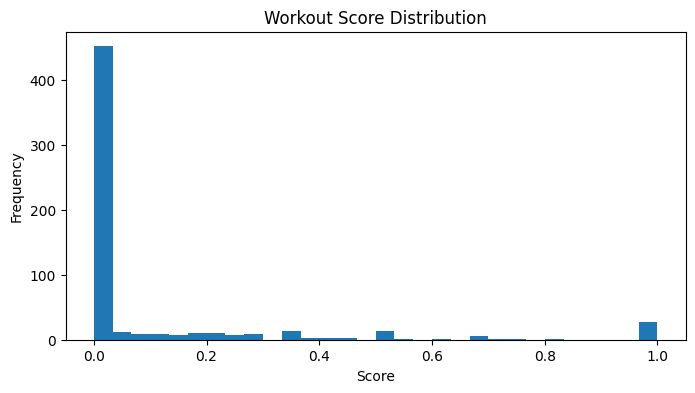

In [ ]:
# Workout score: numeric density + exercise keyword ratio
workout_keywords = {
    'sec', 'second', 'seconds', 'min', 'minute', 'minutes',
    'reps', 'rep', 'sets', 'set',
    'squat', 'plank', 'pushup', 'push', 'pull', 'crunch', 'abs', 'core'
}

def workout_score(text):
    tokens = re.findall(r'[a-z0-9]+', text.lower())
    if not tokens:
        return 0
    num_ratio = sum(tok.isdigit() for tok in tokens) / len(tokens)
    kw_ratio = sum(tok in workout_keywords for tok in tokens) / len(tokens)
    return num_ratio + kw_ratio

df_posts['workout_score'] = df_posts['ocr_text'].apply(workout_score)
df_posts['is_workout'] = df_posts['workout_score'] > 0.05

print(f"Workout pins: {df_posts['is_workout'].sum()} ({df_posts['is_workout'].mean():.1%})")

df_posts['workout_score'].plot(kind='hist', bins=30, figsize=(8, 4), title='Workout Score Distribution')
plt.xlabel('Score')
plt.show()

In [ ]:
# Quote score: stopword ratio * inverse numeric density
def quote_score(text):
    tokens = re.findall(r'[a-z]+', text.lower())
    if not tokens:
        return 0
    stop_ratio = sum(t in stopwords for t in tokens) / len(tokens)
    num_ratio = sum(tok.isdigit() for tok in text.split()) / (len(text.split()) + 1)
    alpha_ratio = len(tokens) / (len(text.split()) + 1)
    return alpha_ratio * stop_ratio * (1 - num_ratio)

df_posts['quote_score'] = df_posts['ocr_text'].apply(quote_score)

print("Top quote pins:")
df_posts.sort_values('quote_score', ascending=False).head(10)[['ocr_text', 'quote_score']]

Top quote pins:


,ocr_text,quote_score
170,ice baths for your face,0.333333
389,For J,0.333333
488,L1an7 L,0.333333
535,For Antad,0.333333
57,How to be a clean girl Pave L liepOst),0.300000
502,chaotic is prganised,0.250000
164,cleaning your fyp,0.250000
243,Clean Gir] [a hecoming the best version of mys...,0.230769
412,We re slowly evolving past the clean girl era ...,0.230769
328,"and then snoor TS ncaaaOS private atn (0"" 1, i...",0.222550


## Thematic Clustering (TF-IDF + K-Means)

OCR strings are vectorized with TF-IDF and clustered into k=5 groups. An elbow curve validates the choice of k.

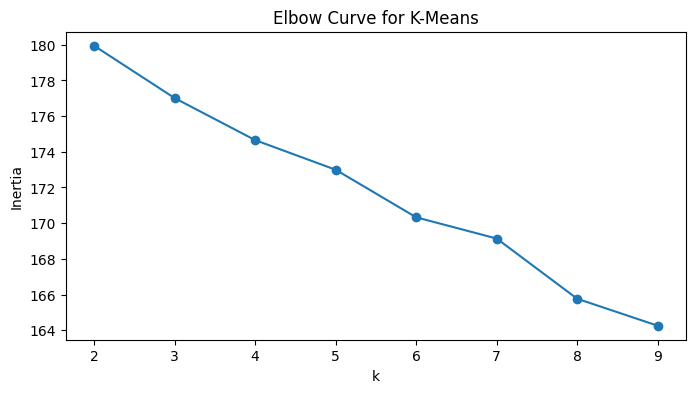

In [ ]:
# Elbow curve to validate k
vec = TfidfVectorizer(min_df=2, max_df=0.8)
X = vec.fit_transform(df_posts['ocr_text'].astype(str))

inertias = []
k_range = range(2, 10)
for k_test in k_range:
    km_test = KMeans(n_clusters=k_test, random_state=42, n_init=10)
    km_test.fit(X)
    inertias.append(km_test.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Curve for K-Means')
plt.show()

In [ ]:
# Fit final model with k=5
k = 5
km = KMeans(n_clusters=k, random_state=42, n_init=10)
df_posts['ocr_cluster'] = km.fit_predict(X)

# Top terms per cluster
terms = vec.get_feature_names_out()
print("Top terms per cluster:")
for c in range(k):
    center = km.cluster_centers_[c]
    top = sorted(zip(center, terms), reverse=True)[:10]
    print(f"\nCluster {c}: {[t for _, t in top]}")

Top terms per cluster:

Cluster 0: ['the', 'for', 'rhode', 'gisou', 'ordinary', 'your', 'vanilla', 'dior', 'and', 'you']

Cluster 1: ['du', 'mask', 'zucker', 'mit', 'zu', 'your', 'you', 'york', 'yoga', 'yet']

Cluster 2: ['ouai', 'oual', 'the', 'qual', 'quai', '36', 'zucker', 'zu', 'your', 'you']

Cluster 3: ['girl', 'clean', 'ouai', 'sundae', 'messy', 'she', 'giri', 'your', 'oua', 'shes']

Cluster 4: ['wear', 'clean', 'trim', 'shower', 'moisturize', 'maintain', 'follow', 'eyebrows', 'deodorant', 'apply']


In [ ]:
# Sample pins per cluster
for c in range(k):
    print(f"\n--- Cluster {c} ---")
    print(df_posts[df_posts['ocr_cluster'] == c]['ocr_text'].head(3).tolist())


--- Cluster 0 ---
['gisou 70n0 Ordinary: Kiko NUTEBOQ die gisou ordlinary: gisou Unidia henar', '1', 'Professionelle Ergebnisse aus der Drogerie?']

--- Cluster 1 ---
['1 IU L 3a" DU Miba PAYNEI Eenacrctol uFU surge mask Htete nuil Vh surge Muug LNIQUE moisture overnight  masque Tydralant CLINIQUE moisture A Atattor hyek Frehydratant loet TOOH borerment', 'Du suchst ein Rezept mit richtig wenig Zucker? MML LecWilyau Exla ZERO GcHWARIAO Exta ZERO ORZUCKERZUSATZ Schwarz" kirsche', "Du 'october {2022"]

--- Cluster 2 ---
['QOUAI OUAI n08 #AvE 3 OUAl ThE 0 15758 37445 d NQ#R Bamboo', 'Ouai Quai Qual OUAi OUAI', '36 OUAI Sok7970 Tans # "4 aiet 1 1 OUAI Ouai E IFO7 687 / [7 - OUAI 5259885 6\'0 2 2']

--- Cluster 3 ---
["Ouai pixou OLAPLEX [ 7i she's a clean girl 5  4| 9", 'OuaI sundae CKARLL CALDAA Jixon clean girl cot M 9 1 Jixou 9 cioui IlIA Crart EL', 'How to be a clean girl Pave L liepOst)']

--- Cluster 4 ---
['HOW TO BEA CLEAN GIRL Daily shower Follow a skincare routine Moisturize bod

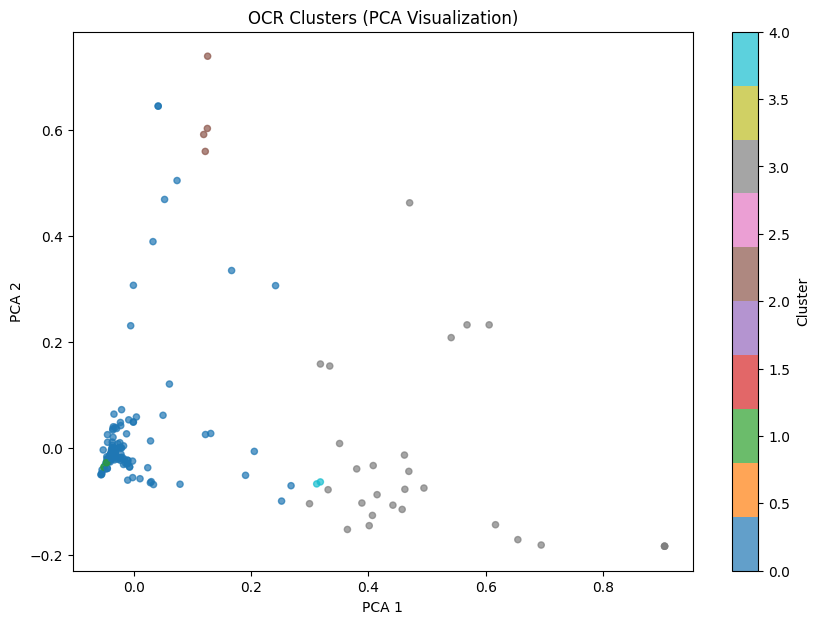

In [ ]:
# PCA visualization of clusters
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X.toarray())
df_posts['pca_x'] = coords[:, 0]
df_posts['pca_y'] = coords[:, 1]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df_posts['pca_x'], df_posts['pca_y'],
    c=df_posts['ocr_cluster'], cmap='tab10', alpha=0.7, s=20
)
plt.title('OCR Clusters (PCA Visualization)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(scatter, label='Cluster')
plt.show()

## Caption vs. OCR Similarity (Jaccard)

In [ ]:
def jaccard(a, b):
    a = str(a) if pd.notna(a) else ''
    b = str(b) if pd.notna(b) else ''
    A = set(a.lower().split())
    B = set(b.lower().split())
    if not A or not B:
        return 0
    return len(A & B) / len(A | B)

df_posts['caption_ocr_similarity'] = df_posts.apply(
    lambda r: jaccard(r['description'], r['ocr_text']), axis=1
)

print("Jaccard similarity (caption vs. OCR):")
print(df_posts['caption_ocr_similarity'].describe())

Jaccard similarity (caption vs. OCR):
count    600.000000
mean       0.008701
std        0.040628
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.500000
Name: caption_ocr_similarity, dtype: float64


In [ ]:
# Pins with highest overlap between caption and OCR
df_posts.sort_values('caption_ocr_similarity', ascending=False).head(10)[['description', 'ocr_text', 'caption_ocr_similarity']]

,description,ocr_text,caption_ocr_similarity
184,fond d'ecran clean girl,Clean Girl,0.500000
265,she's a CLEAN GIRL 🥰,shes a clean girl 74 Ouai,0.375000
281,Syoss Permanente Coloration für bis zu 100 Tag...,8 BIS ZU 100 TAGE FARBINTENSITAT,0.363636
193,Clean tips,Clean girl Uh,0.250000
104,Schwarzkopf BRILLANCE Haar Glossing Kühles Blond,KUHLES BLOND MIT BRILLANCE Schwarzkopf ANTI-GE...,0.250000
159,"Langes starkes Haar, starke Formel: Niacinamid...",NIVEA PFLEGT UND STARKT DIE HAARSTRUKTUR UNTER...,0.187500
19,Verschenke Dyson Beauty,05 supersonic nural Verschenke gesunderes Haar...,0.181818
86,Stärkt die Haarstruktur & reduziert Spliss – f...,NIVEA MIT HOCHWIRKSAMEM NIACINAMID UND NATURLI...,0.166667
131,Dein langes Haar wird’s lieben 💕 Die NIVEA Len...,NIVEA MIT HOCHWIRKSAMEM NIACINAMID UND NATURLI...,0.159091
198,Du suchst ein leckeres Frühstück mit viel Prot...,Du suchst ein Rezept mit richtig wenig Zucker?...,0.157895


## Visualization

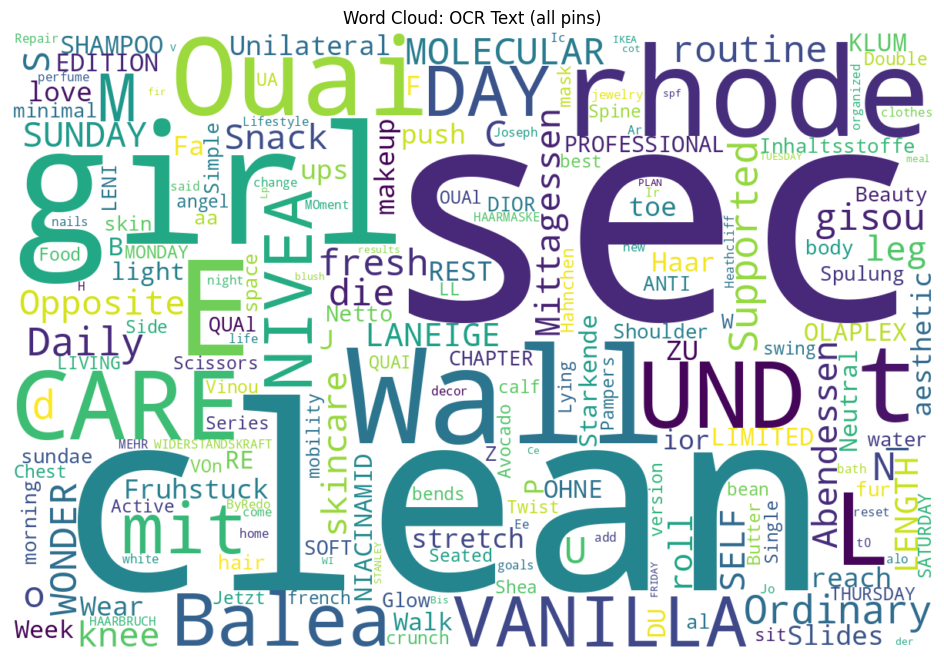

In [ ]:
# Word cloud of all OCR text
text = ' '.join(df_posts['ocr_text'].astype(str))

wc = WordCloud(
    width=1200, height=800,
    background_color='white',
    collocations=False,
    max_words=200
).generate(text)

plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: OCR Text (all pins)')
plt.show()

## Export

In [ ]:
OUTPUT_PATH = '/content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/combined_df_ocr.csv'

df_posts.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to {OUTPUT_PATH}")
print(f"Columns: {list(df_posts.columns)}")

Saved to /content/drive/MyDrive/Team Dattel/Computational Social Media Analysis/Preprocessing Data/combined_df_ocr.csv
Columns: ['pin_id', 'title', 'description', 'domain', 'board', 'created_at', 'image_url', 'category', 'ocr_text', 'ocr_normalized', 'caption_len', 'ocr_len', 'brands_ocr', 'workout_score', 'is_workout', 'quote_score', 'ocr_cluster', 'pca_x', 'pca_y', 'caption_ocr_similarity']
